# Retail Demand Forecasting

This notebook demonstrates an end-to-end forecasting pipeline using the Retail Store Inventory Dataset.
We will aggregate daily sales to weekly product-store sales, explore the data, train baseline models, 
and evaluate forecasts using RMSE, MAE, and sMAPE.

### Goals
- Aggregate transactional sales to weekly product-store level.
- Explore seasonality and trends.
- Train and compare multiple forecasting models.
- Evaluate forecasts and provide insights for inventory and sales planning.

### 1. Setup and Dependencies

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

#forecasting/model libs
from prophet import Prophet
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("all modules loaded successfully")

all modules loaded successfully


### 2. Load Dataset

In [ ]:
#load dataset
df = pd.read_csv('../data/retail_store_inventory.csv')

#overview
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

### 3. Preprocessing

In [46]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [31]:
#ensure Date column exists, and adapt if necessary
df['Date'] = pd.to_datetime(df['Date'])

#aggregate weekly sales per product
group_cols = ['Store ID', 'Product ID']

df_weekly = (
    df.groupby(group_cols + [pd.Grouper(key='Date', freq='W-MON')])
    .agg({'Units Sold': 'sum'})
    .reset_index()
    .rename(columns={'Date': 'Week Start'})
)

df_weekly.head()

,Store ID,Product ID,Week Start,Units Sold
0,S001,P0001,2022-01-03,213
1,S001,P0001,2022-01-10,737
2,S001,P0001,2022-01-17,719
3,S001,P0001,2022-01-24,1082
4,S001,P0001,2022-01-31,876


### 4. Exploratory Data Analysis

Before modelling lets start by getting an overview over the data, and potentially see if there any obvious correlations or potential biasies.

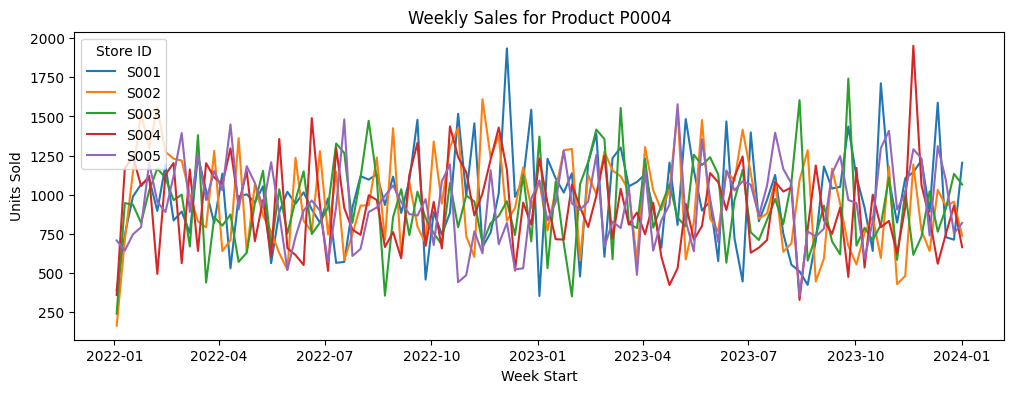

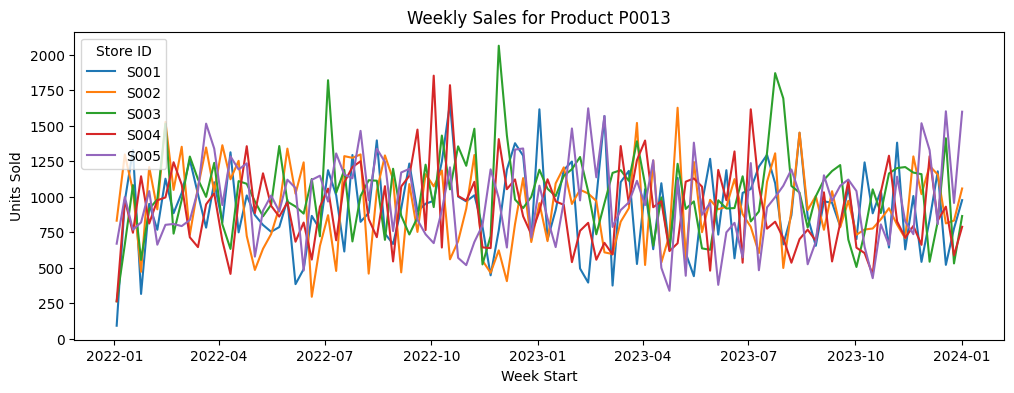

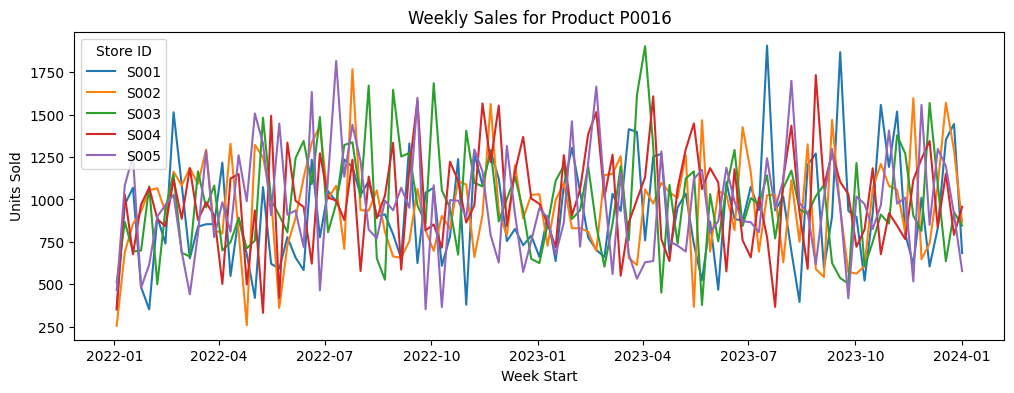

In [61]:
sample = df_weekly.sample(3)['Product ID'].values

for product in sample:
    temp = df_weekly[df_weekly['Product ID'] == product]
    plt.figure(figsize=(12,4))
    sns.lineplot(x='Week Start', y='Units Sold', hue='Store ID', data=temp)
    plt.title(f"Weekly Sales for Product {product}")
    plt.show()

### 5. Define Evaluation Metrics

To evaluate the performace of the forecasting models we can use a 

- **RMSE**: average squared differences between predicted values and actual values. Penalizes large errors more than small errors. lower means prediction closer to actual.
- **MAE**: the average absolute difference between actual and predicted. All errors are treated equally without regard for size. Gives a clear sense of average deviation. lower value -> better forecast.
- **sMAP**: metric used to measure the accuracy of forecasts, perfect match (0) and no match at all (1). Value is a percentage-based error relative to the magnitude of actual and predicted values.

In [90]:
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def evaluate(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=True)
    mae = mean_absolute_error(y_true, y_pred)
    smape_val = smape(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "sMAPE": smape_val}

### 6. Baseline Model: Prophet

17:45:38 - cmdstanpy - INFO - Chain [1] start processing
17:45:38 - cmdstanpy - INFO - Chain [1] done processing


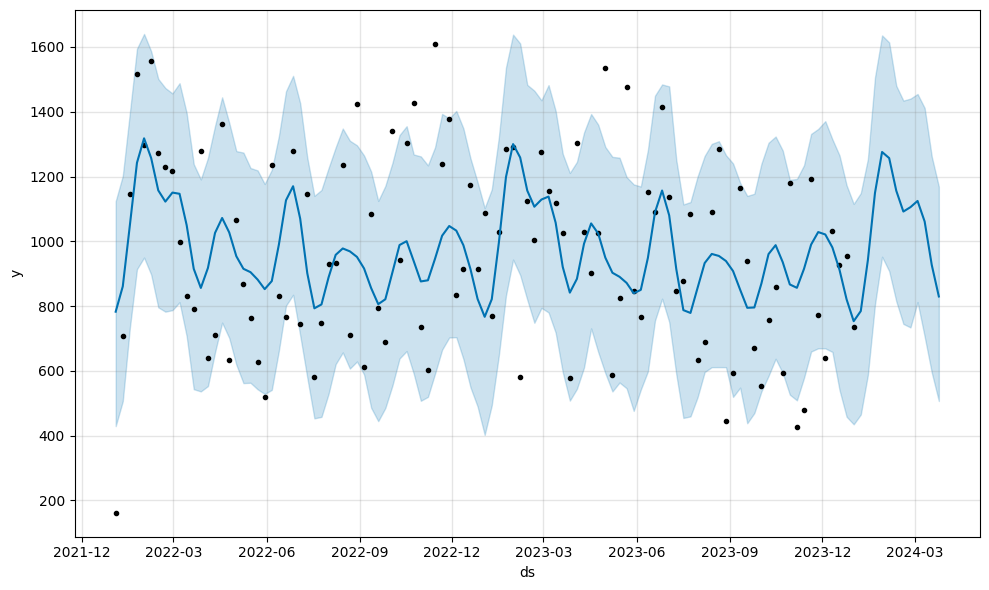

TypeError: got an unexpected keyword argument 'squared'

In [91]:
# Example: single product-store
example = df_weekly[(df_weekly['Product ID'] == sample[0]) & (df_weekly['Store ID'] == "S002")]

prophet_df = example.rename(columns={'Week Start':'ds', 'Units Sold':'y'})

model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq='W-MON')
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.show()

# Evaluate on last 12 weeks
y_true = prophet_df['y'].values[-12:]
y_pred = forecast['yhat'].values[-12:]
evaluate(y_true, y_pred)

In [92]:
help(mean_squared_error)


Help on function mean_squared_error in module sklearn.metrics._regression:

mean_squared_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')
    Mean squared error regression loss.

    Read more in the :ref:`User Guide <mean_squared_error>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Estimated target values.

    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.

    multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
        Defines aggregating of multiple output values.
        Array-like value defines weights used to average errors.

        'raw_values' :
            Returns a full set of errors in case of multioutput input.

        'uniform_average' :
            Er

In [ ]:
import inspect
print()